# Send more money!
**Course:** Data Structures & Algorithms 1

## Implementation

In [22]:
def getUniqueLetters(words):
    seen = []
    max_len = max(len(w) for w in words)
    for col in range(max_len):
        for word in words:
            idx = len(word) - 1 - col
            if idx >= 0 and word[idx] not in seen:
                seen.append(word[idx])
    return seen

def getFirstLetters(words):
    firstLetters = []

    for i in range(len(words)):
        firstLetters.append(words[i][0])

    return firstLetters

def assignCoversionToWord(word, mappings):
    num = 0
    for i in range(len(word)):
        num = num * 10 + mappings[word[i]]

    return num

def checkSuffice(words, mappings):
    addends, result = words[:-1], words[-1]
    max_len = max(len(w) for w in words)
    carry = 0

    for col in range(max_len):
        col_letters = [word[len(word) - 1 - col]
                       for word in addends if len(word) - 1 - col >= 0]
        result_idx = len(result) - 1 - col
        if result_idx >= 0:
            col_letters.append(result[result_idx])

        if any(ch not in mappings for ch in col_letters):
            break

        col_sum = carry + sum(mappings[word[len(word) - 1 - col]]
                              for word in addends if len(word) - 1 - col >= 0)

        if result_idx >= 0:
            if col_sum % 10 != mappings[result[result_idx]]:
                return False
            carry = col_sum // 10
        else:
            if col_sum % 10 != 0:
                return False
            carry = col_sum // 10

    return True

def printSolution(words, mappings):
    for i in range(len(words)-1):
        print(str(assignCoversionToWord(words[i], mappings)) + " +")
    print(" = " + str(assignCoversionToWord(words[len(words)-1], mappings)))
    

def solveCryptarithmetic(letterIndex, words, mappings, firstLetters, uniqueLetters):

    if len(words) == 0:
        return False

    if letterIndex == len(uniqueLetters):
        return checkSuffice(words, mappings)

    
    for i in range(10):
        if (firstLetters.count(uniqueLetters[letterIndex]) != 0 and i == 0) or i in mappings.values():
            continue
        
        mappings[uniqueLetters[letterIndex]] = i

        if checkSuffice(words, mappings):
            if solveCryptarithmetic(letterIndex + 1, words, mappings, firstLetters, uniqueLetters):
                return True
        
        mappings.pop(uniqueLetters[letterIndex])

    return False    

words = ["SEND", "MORE", "MONEY"]

firstLetters = getFirstLetters(words)
uniqueLetters = getUniqueLetters(words)
mappings = {}

if solveCryptarithmetic(0, words, mappings, firstLetters, uniqueLetters):
    printSolution(words, mappings)
else:
    print("No solution")

9567 +
1085 +
 = 10652


For this problem we use the backtracking algorithm to find a solution for the cryptarithmetic puzzle, if one exists. What the algorithm does is it assigns a number to each uniqe letter from a word. After we have assigned a number to all letters from one column, we check if the result is valid, is it is not we backtrack, or in other words start over from the top letter in the column. That is repeated until all columns come out correct or until we run out of combinations if there isn't a solution to the puzzle.

## Performance test

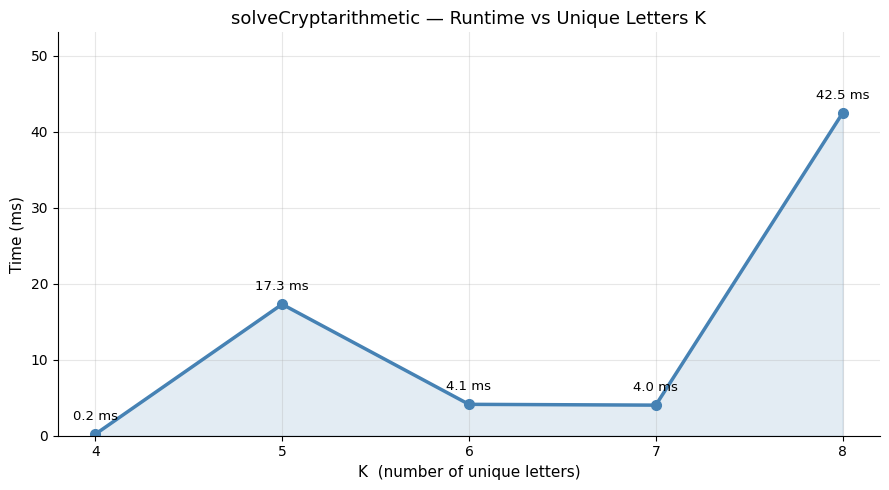

In [25]:
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

puzzles = [
    (4, ["GO",    "TO",    "OUT"   ]),
    (5, ["AB",    "CD",    "ACE"   ]),
    (6, ["ABCD",  "EF",    "AEFCD" ]),
    (7, ["ABCDE", "FG",    "AFGCDE"]),
    (8, ["SEND",  "MORE",  "MONEY" ]),
]

k_values, times = [], []

for k, puzzle in puzzles:
    fl = getFirstLetters(puzzle)
    ul = getUniqueLetters(puzzle)
    k_actual = len(ul)
    start = time.perf_counter()
    solveCryptarithmetic(0, puzzle, {}, fl, ul)
    end = time.perf_counter()
    k_values.append(k_actual)
    times.append((end - start) * 1000)


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, times, color='steelblue', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(k_values, times, alpha=0.15, color='steelblue')

for x, y in zip(k_values, times):
    ax.annotate(f"{y:.1f} ms", xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9.5)

ax.set_xlabel('K  (number of unique letters)', fontsize=11)
ax.set_ylabel('Time (ms)', fontsize=11)
ax.set_title('solveCryptarithmetic — Runtime vs Unique Letters K', fontsize=13)
ax.set_xticks(k_values)
ax.set_ylim(bottom=0, top=max(times) * 1.25)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig('performance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Complexity Analysis

Since in the worst case we can have  10 unique characters, and for every next character the options become -1: for the first letter 10, then 9, 8, etc. and the algorithm would have to try all possible combinations, before finding the right one if it exists, thus why it's complexity is O(n!).

## Unit tests

In [18]:
import unittest

class TestsolveCryptarithmetic(unittest.TestCase):
    def test_solvable_Cryptarithmetic(self):
        self.assertEqual(solveCryptarithmetic(0, ["SEND","MORE","MONEY"], {}, ["S","M","M"], ["D", "E", "Y", "N", "R", "O", "S", "M"]), True)

    def test_unsolvable_Cryptarithmetic(self):
        self.assertEqual(solveCryptarithmetic(0, ["I","AM","HERE"], {}, ["I","A","H"], ["I","A","M","H","E","R"]), False)

    def test_word_not_in_file(self):
        self.assertEqual(solveCryptarithmetic(0, [], {}, [], []), False)

unittest.main(argv=[""], exit=False, verbosity=2)


test_solvable_Cryptarithmetic (__main__.TestsolveCryptarithmetic.test_solvable_Cryptarithmetic) ... ok
test_unsolvable_Cryptarithmetic (__main__.TestsolveCryptarithmetic.test_unsolvable_Cryptarithmetic) ... ok
test_word_not_in_file (__main__.TestsolveCryptarithmetic.test_word_not_in_file) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.183s

OK
